# Diagonalización exacta del Ising con campo transverso

Este notebook resuelve por ED el mismo sistema de 20 spins y recupera el vector de estado fundamental para cada campo transversal h = 0.2, 0.4, ..., 2.0. Usa un operador disperso matricial-free en CPU, por lo que puede ejecutarse en paralelo con los VQE que usan la GPU.

No se construye la matriz densa de dimensión 2^20 por 2^20. El resultado se guarda en formato comprimido como una matriz de estados de forma 10 x 2^20.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / 'exact_diagonalization.py').exists():
    NOTEBOOK_DIR = Path('Tensor Networks/ising con campo transverso').resolve()
sys.path.insert(0, str(NOTEBOOK_DIR))

from exact_diagonalization import (
    DEFAULT_FIELDS,
    diagonalize_grid,
    save_ed_results,
)

ROOT = NOTEBOOK_DIR
RESULTS_DIR = ROOT / 'results'
NUM_SPINS = 20
COUPLING_J = 1.0
print(f'Campos: {list(DEFAULT_FIELDS)}')
print(f'Hilbert: 2^{NUM_SPINS} = {2**NUM_SPINS} amplitudes')
print('Motor: scipy.sparse.linalg.eigsh con LinearOperator en CPU')

Campos: [np.float64(0.2), np.float64(0.4), np.float64(0.6), np.float64(0.8), np.float64(1.0), np.float64(1.2), np.float64(1.4), np.float64(1.6), np.float64(1.8), np.float64(2.0)]
Hilbert: 2^20 = 1048576 amplitudes
Motor: scipy.sparse.linalg.eigsh con LinearOperator en CPU


## Resolver todos los campos por ED

La continuación de la celda usa el estado fundamental anterior como vector inicial de Krylov para acelerar el siguiente campo. Cada estado recuperado se conserva en la variable ground_states y también se escribe en disco.

In [2]:
RUN_ED = False

if RUN_ED:
    ed_results, ground_states = diagonalize_grid(
        fields=DEFAULT_FIELDS,
        num_spins=NUM_SPINS,
        coupling=COUPLING_J,
        tolerance=1e-9,
        max_iterations=1000,
        krylov_vectors=24,
    )
    saved_paths = save_ed_results(ed_results, ground_states, RESULTS_DIR)
    fields = np.asarray(DEFAULT_FIELDS, dtype=float)
    energies = np.asarray([row['energy'] for row in ed_results])
    print(f'{len(ed_results)} campos resueltos por ED')
    print(saved_paths)
else:
    metadata_path = RESULTS_DIR / 'ed_ground_state_metadata.json'
    states_path = RESULTS_DIR / 'ed_ground_states.npz'
    if not metadata_path.exists() or not states_path.exists():
        raise FileNotFoundError('Activa RUN_ED = True para generar los resultados de ED.')
    ed_results = json.loads(metadata_path.read_text(encoding='utf-8'))
    archive = np.load(states_path)
    fields = archive['fields']
    energies = archive['energies']
    ground_states = archive['ground_states']
    print(f'{len(ed_results)} campos cargados desde {states_path}')

10 campos cargados desde C:\Users\the_b\Desktop\Tareas universidad\Información y Computación Cuántica\Directorios GitHub\Quantum-Computing-Personal-Projects\Tensor Networks\ising con campo transverso\results\ed_ground_states.npz


In [3]:
print('Tabla de energías fundamentales:')
for row in ed_results:
    print(
        f"h={row['transverse_field_h']:.1f} | E0={row['energy']:.10f} | "
        f"residuo={row['residual_norm']:.3e} | norma={row['state_norm']:.8f}"
    )

assert ground_states.shape == (len(DEFAULT_FIELDS), 2**NUM_SPINS)
assert np.allclose(np.linalg.norm(ground_states, axis=1), 1.0, atol=1e-7)
assert max(row['residual_norm'] for row in ed_results) < 1e-6
print(f'ground_states.shape = {ground_states.shape}')
print('Validación ED correcta: estados normalizados y residuos pequeños.')

Tabla de energías fundamentales:
h=0.2 | E0=-19.2206066117 | residuo=4.368e-09 | norma=1.00000000
h=0.4 | E0=-19.8900466109 | residuo=1.681e-08 | norma=1.00000000
h=0.6 | E0=-21.0342537239 | residuo=9.692e-10 | norma=1.00000000
h=0.8 | E0=-22.7155076071 | residuo=3.046e-09 | norma=1.00000000
h=1.0 | E0=-25.1077971116 | residuo=2.331e-09 | norma=1.00000000
h=1.2 | E0=-28.1434725234 | residuo=2.128e-08 | norma=1.00000000
h=1.4 | E0=-31.5029566733 | residuo=1.769e-09 | norma=1.00000000
h=1.6 | E0=-35.0400728538 | residuo=3.230e-08 | norma=1.00000000
h=1.8 | E0=-38.6879082980 | residuo=8.335e-09 | norma=1.00000000
h=2.0 | E0=-42.4102073143 | residuo=2.262e-09 | norma=1.00000000
ground_states.shape = (10, 1048576)
Validación ED correcta: estados normalizados y residuos pequeños.


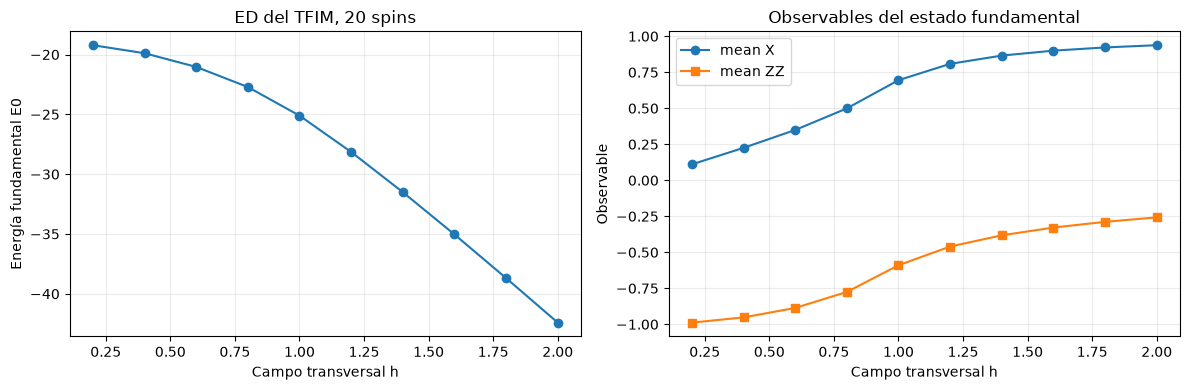

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(fields, energies, 'o-', color='tab:blue')
axes[0].set_xlabel('Campo transversal h')
axes[0].set_ylabel('Energía fundamental E0')
axes[0].set_title('ED del TFIM, 20 spins')
axes[0].grid(alpha=0.25)

axes[1].plot(fields, [row['mean_X'] for row in ed_results], 'o-', label='mean X')
axes[1].plot(fields, [row['mean_ZZ'] for row in ed_results], 's-', label='mean ZZ')
axes[1].set_xlabel('Campo transversal h')
axes[1].set_ylabel('Observable')
axes[1].set_title('Observables del estado fundamental')
axes[1].grid(alpha=0.25)
axes[1].legend()
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'ed_ground_state_summary.png', dpi=160)
plt.show()

## Recuperación de un estado fundamental

ground_states[i] es el vector de amplitudes del estado fundamental correspondiente a fields[i], en la base computacional ordenada por el índice entero de los bits. Por ejemplo, el estado para el primer campo se recupera así:

In [5]:
field_index = 0
selected_field = float(fields[field_index])
selected_ground_state = ground_states[field_index]
largest_amplitudes = np.argsort(np.abs(selected_ground_state))[-10:][::-1]

print(f'Campo seleccionado: h={selected_field:.1f}')
print(f'Vector recuperado: forma={selected_ground_state.shape}, dtype={selected_ground_state.dtype}')
print('Diez amplitudes de mayor magnitud:')
for basis_index in largest_amplitudes:
    bitstring = format(int(basis_index), f'0{NUM_SPINS}b')
    amplitude = selected_ground_state[basis_index]
    print(f'|{bitstring}>: {amplitude:+.8e}')

Campo seleccionado: h=0.2
Vector recuperado: forma=(1048576,), dtype=float64
Diez amplitudes de mayor magnitud:
|11111111111111111111>: -8.97142781e-01
|00000000000000000000>: -3.62459264e-01
|01111111111111111111>: -8.97142781e-02
|11111111111111111110>: -8.97142779e-02
|11111111111111111101>: -4.53057104e-02
|10111111111111111111>: -4.53057104e-02
|11011111111111111111>: -4.49760105e-02
|11111111111111111011>: -4.49760105e-02
|11101111111111111111>: -4.49705435e-02
|11111111111111110111>: -4.49705435e-02
